In [1]:
!pip install statsbombpy mplsoccer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.3/108.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.9 MB/s eta 0:00:00


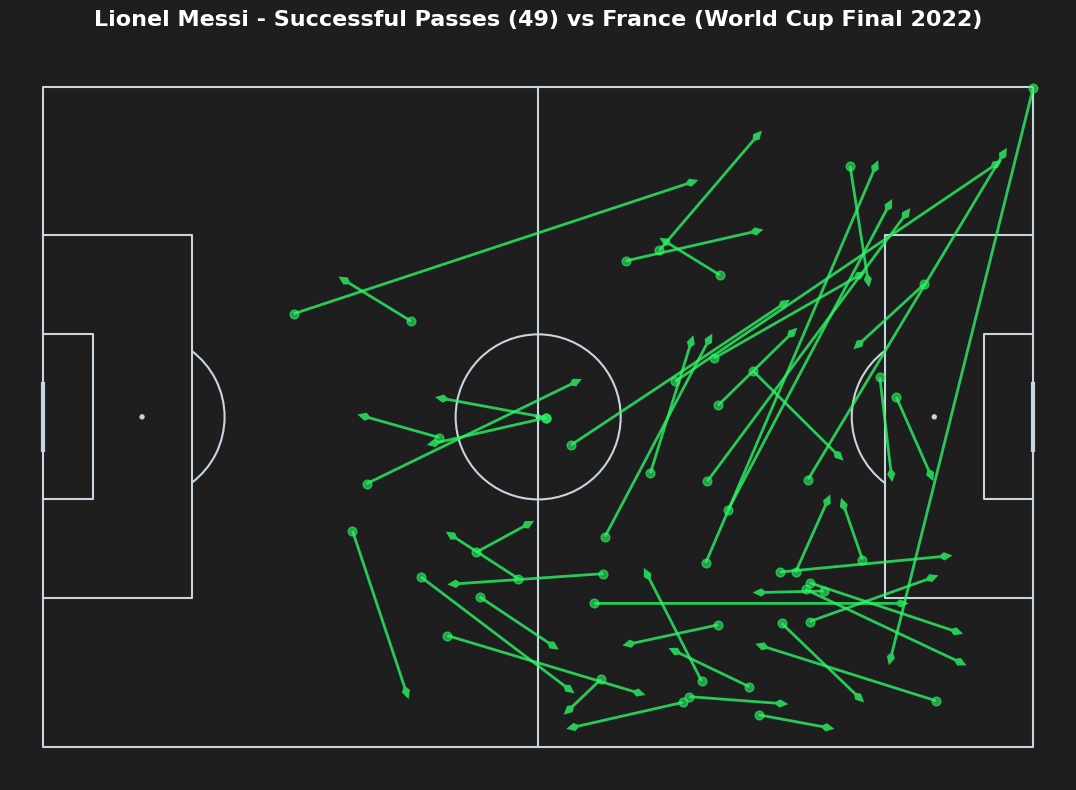

In [8]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from statsbombpy import sb

# 1. Изтегляме събитията за мача
match_events = sb.events(match_id=3869685)

# 2. Филтрираме пасовете – ползваме 'contains', за да открием Меси независимо от пълното му име
messi_passes = match_events[
    (match_events["type"] == "Pass")
    & (
        match_events["player"]
        .str.contains("Messi", na=False, case=False)
    )
].copy()

# 3. Вземаме само успешните пасове (pass_outcome е NaN)
successful_passes = messi_passes[
    messi_passes["pass_outcome"].isna()
].copy()

# 4. Извличаме координатите безопасно
x = [loc[0] for loc in successful_passes["location"]]
y = [loc[1] for loc in successful_passes["location"]]
end_x = [loc[0] for loc in successful_passes["pass_end_location"]]
end_y = [loc[1] for loc in successful_passes["pass_end_location"]]

# 5. Начертаване на терена и пасовете
pitch = Pitch(
    pitch_type="statsbomb",
    pitch_color="#1e1e1e",
    line_color="#c7d5e0",
    linewidth=1.5,
)
fig, ax = pitch.draw(figsize=(12, 8))
fig.set_facecolor("#1e1e1e")

# 6. Добавяне на стрелките и точките
pitch.arrows(
    x,
    y,
    end_x,
    end_y,
    ax=ax,
    color="#2bf666",
    width=2,
    headwidth=3,
    headlength=3,
    alpha=0.8,
)

pitch.scatter(x, y, ax=ax, color="#2bf666", s=40, alpha=0.6)

plt.title(
    f"Lionel Messi - Successful Passes ({len(successful_passes)}) vs France (World Cup Final 2022)",
    color="white",
    fontsize=16,
    pad=20,
    fontweight="bold",
)
plt.savefig("messi_passes_final2022.png", dpi=300, bbox_inches="tight")
plt.show()